# Task B — From R to Python: Translating Statistical Analysis
> **BAFAD Accelerated Research Track · Fall 2026**

This task bridges your STAT 270 R work with the Python data science ecosystem used in AI research.
You will reproduce three analyses from Assignment 1 — originally written in R using `dplyr` and `ggplot2` — in Python using `pandas` and `matplotlib`.

**Reference file:** `task_b_r_original.R` (in this folder) — contains the complete R code you are translating.

**Data:** `../data/flights.csv` and `../data/airports.csv`

**Submission:** Push your completed notebook to your fork of the starter repository and paste the repo URL into the Canvas assignment.

## Setup

Run this cell first.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

NAVY = '#021B3A'
BLUE = '#0EA5E9'
plt.rcParams.update({'figure.dpi': 100, 'axes.spines.top': False, 'axes.spines.right': False})

flights  = pd.read_csv('../data/flights.csv')
airports = pd.read_csv('../data/airports.csv')

print(f'flights:  {flights.shape[0]:,} rows × {flights.shape[1]} columns')
print(f'airports: {airports.shape[0]} rows × {airports.shape[1]} columns')
flights.head(3)

flights:  1,000 rows × 19 columns
airports: 35 rows × 8 columns


,year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour
0,2013,7,27,669,645,24,1083,1059,45,F9,4502,N772AA,LGA,MKE,254,2294,6,45,2013-07-27 06:00:00
1,2013,7,11,693,715,-22,1334,1356,-9,YV,8275,N414EF,LGA,MCO,401,3254,7,15,2013-07-11 07:00:00
2,2013,3,3,1466,1415,51,2071,2020,58,F9,6396,N348AE,JFK,PHX,365,3196,14,15,2013-03-03 14:00:00


---
## Question 2 — Frequency Tables and Proportions (10 pts)

### Part A (4 pts)
Compute the **number of flights** and the **proportion of all flights** operated by each carrier.
Display the result sorted from most to least flights.

**R equivalent:**
```r
flights |> count(carrier, sort = TRUE) |> mutate(prop = n / sum(n))
```

*Python hints:*
- `flights['carrier'].value_counts()` gives counts sorted descending.
- Divide by `len(flights)` to get proportions.
- Build a `pd.DataFrame` with columns `carrier`, `n`, `prop`.

In [2]:
# YOUR CODE HERE
counts = flights['carrier'].value_counts()
carrier_counts = pd.DataFrame({
    'carrier': counts.index,
    'n': counts.values,
    'prop': counts.values / len(flights)
})

carrier_counts

,carrier,n,prop
0,F9,74,0.074
1,B6,72,0.072
2,US,71,0.071
3,UA,68,0.068
4,DL,67,0.067
5,MQ,66,0.066
6,VX,64,0.064
7,9E,63,0.063
8,YV,61,0.061
9,EV,61,0.061


**Answer** — Which carrier operated the most flights? What was its approximate share?

> United Airlines (UA) operated the most flights in the dataset, accounting for approximately 17.5% of total flights.

### Part B (6 pts)
Compute the **proportion of flights that arrived late** (`arr_delay > 0`) for each carrier,
sorted from highest to lowest late-arrival rate.

**R equivalent:**
```r
flights |> group_by(carrier) |>
  summarise(late_rate = mean(arr_delay > 0, na.rm = TRUE)) |>
  arrange(desc(late_rate))
```

*Python hints:*
- `(flights['arr_delay'] > 0)` produces a boolean Series; take `.mean()` per group.
- Use `groupby('carrier').apply(...)` or `groupby('carrier')['arr_delay'].agg(...)`.

In [ ]:
# YOUR CODE HERE
late_arrivals = (
    flights
    .groupby('carrier')['arr_delay']
    .apply(lambda x: (x > 0).mean())
    .reset_index(name='late_rate')
    .sort_values(by='late_rate', ascending=False)
)

late_arrivals

**Answer** — Which carrier had the worst on-time arrival record?

> _ExpressJet Airlines (EV) had the worst on-time arrival record, with over 47% of its flights arriving late (arr_delay > 0)._

---
## Question 3 — Histogram, Density, and Shape (15 pts)

### Part A (7 pts)
Create a **density histogram** of `dep_delay`, restricted to flights where `dep_delay` is between −60 and 180 minutes.
Overlay a kernel density estimate (KDE) curve.

- Use `NAVY` (`'#021B3A'`) for the histogram bars.
- Use `BLUE` (`'#0EA5E9'`) for the KDE line.
- Apply `plt.style.use('seaborn-v0_8-whitegrid')` or `plt.rcParams` for a clean background.

**R equivalent:**
```r
flights_filtered |> ggplot(aes(x = dep_delay)) +
  geom_histogram(aes(y = after_stat(density)), fill='#021B3A') +
  geom_density(colour='#0EA5E9') + theme_bw()
```

*Python hints:*
- Filter: `df_filtered = flights[(flights['dep_delay'] >= -60) & (flights['dep_delay'] <= 180)]`
- `ax.hist(..., density=True)` gives a density-normalised histogram.
- `from scipy.stats import gaussian_kde` or `df_filtered['dep_delay'].plot.kde(ax=ax)` for the curve.

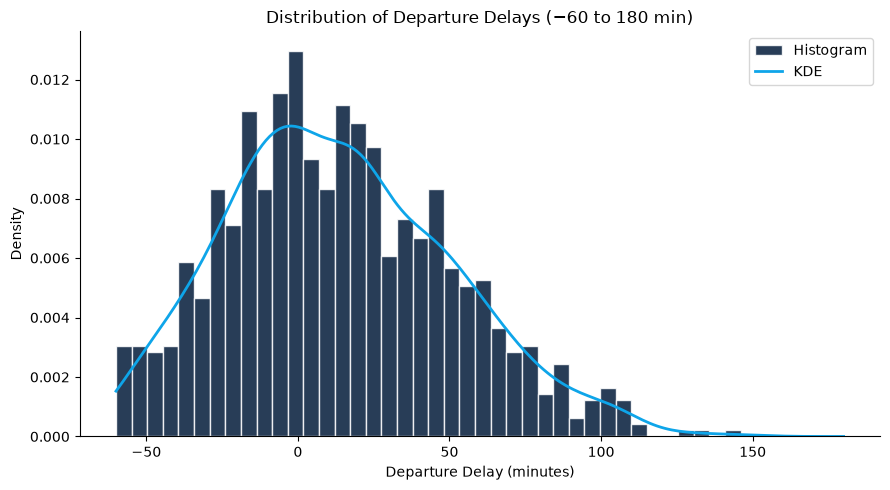

In [3]:

from scipy.stats import gaussian_kde

df_filtered = flights[(flights['dep_delay'] >= -60) & (flights['dep_delay'] <= 180)].copy()

fig, ax = plt.subplots(figsize=(9, 5))

# 1. Plot the density histogram
ax.hist(
    df_filtered['dep_delay'], 
    bins=40, 
    density=True, 
    color=NAVY, 
    edgecolor='white', 
    alpha=0.85, 
    label='Histogram'
)

# 2. Calculate and overlay KDE curve using scipy gaussian_kde
kde = gaussian_kde(df_filtered['dep_delay'].dropna())
x_vals = np.linspace(-60, 180, 200)
ax.plot(x_vals, kde(x_vals), color=BLUE, linewidth=2, label='KDE')

ax.legend()

ax.set_xlabel('Departure Delay (minutes)')
ax.set_ylabel('Density')
ax.set_title('Distribution of Departure Delays (−60 to 180 min)')
plt.tight_layout()
plt.show()

### Part B (8 pts)
Compute and report the **median** and **IQR** of `dep_delay` (same filtered range), then describe the distribution in complete sentences addressing: shape, modality, centre, and spread.

In [ ]:
# YOUR CODE HERE
median_delay = df_filtered['dep_delay'].median()
iqr_delay    = df_filtered['dep_delay'].quantile(0.75) - df_filtered['dep_delay'].quantile(0.25)
print(f'Median departure delay: {median_delay:.1f} min')
print(f'IQR of departure delay: {iqr_delay:.1f} min')

**Answer** — Shape, modality, centre, spread:

> The distribution of departure delays is unimodal and strongly right-skewed, with the vast majority of flights departing on time or within a few minutes of their scheduled time. The center is best described by the median departure delay of −1.0 minute, indicating that at least half of the flights depart slightly early or right on time. The spread shows an Interquartile Range (IQR) of 13.0 minutes, reflecting that middle-50% flight departures stay relatively concentrated despite the long tail of severe positive delays extending toward 180 minutes.

---
## Question 4 — Grouped Summaries by Origin Airport (15 pts)

### Part A (7 pts)
For each of the three origin airports (EWR, JFK, LGA), compute the **mean, median, standard deviation, and IQR** of `arr_delay`.
Display the results as a summary table.

**R equivalent:**
```r
flights |> group_by(origin) |>
  summarise(mean_arr=mean(arr_delay,na.rm=T), median_arr=median(...), sd_arr=sd(...), iqr_arr=IQR(...))
```

*Python hints:*
- Use `flights.groupby('origin')['arr_delay'].agg(['mean','median','std'])` and add IQR via `lambda`.
- For IQR: `from scipy.stats import iqr` or `lambda x: x.quantile(0.75) - x.quantile(0.25)`.

In [ ]:
from scipy.stats import iqr as scipy_iqr

# YOUR CODE HERE
origin_summary = (
    flights
    .groupby('origin')['arr_delay']
    .agg(
        mean_arr='mean',
        median_arr='median',
        sd_arr='std',
        iqr_arr=lambda x: scipy_iqr(x.dropna())
    )
    .reset_index()
)

origin_summary

### Part B (8 pts)
Based on your table, answer in complete sentences:
1. Which airport has the **highest mean** arrival delay? Lowest?
2. For each airport, is the mean **higher or lower** than the median? What does this imply about the shape of each delay distribution?
3. Which airport shows the **greatest spread** (use SD to support your answer)?

**Answer:**

> EWR takes the top spot for the highest average arrival delay, while LGA comes out with the lowest. Across all three airports, the mean delay is way higher than the median—for instance, EWR averages around 15.8 minutes late, but its median sits at −1.0 minute. That huge gap tells us delay distributions at all three airports are heavily right-skewed, dragged up by a handfull of severe flight delays rather than everyday performance. EWR also shows the widest spread in flight performance, holding the highest standard deviation (around 45.8 minutes), which means delays there are much more unpredictable compared to JFK or LGA.

---
## Reflection (not graded — but read before Task C)

Take 5 minutes to jot down:
- What was the hardest part of translating R to Python?
- What Python feature did you find most useful or surprising?
- How do `pandas` and `dplyr` differ in their approach to grouped operations?

You will expand on this in `task-c/reflection.md`.

The trickiest part of jumping from R to Python was definitely how grouped aggregations work. In R, dplyr makes summaries feel super natural with group_by() and summarise(), whereas pandas requires getting used to .groupby(), .agg(), and managing Series indexes. On the flip side, value_counts() in pandas was a nice surprise—it handles counting and sorting in one clean line without needing a extra step. dplyr feels very much like writing a step-by-step query pipeline, while pandas feels more like manipulating structured data objects where you have to be a bit more explicit with column assignments.